### EXTENDING SINGLE HEAD ATTENTION TO MULTI-HEAD ATTENTION

In [1]:
import torch
import torch.nn as nn

class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out 
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)    

        # calculate attention scores
        attn_scores = queries @ keys.transpose(1,2)

        # mask the attention scores to prevent attending to future tokens
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        
        # calculate attention weights
        attn_weights = torch.softmax(attn_scores / (keys.shape[-1] ** 0.5), dim=-1)

        # apply dropout to attention weights
        attn_weights = self.dropout(attn_weights)

        # calculate context vectors as weighted sum of values
        context_vectors = attn_weights @ values
        
        return context_vectors

In practical terms, implementing multi-head attention involves creating multiple instances of self-attention mechanism, each with it's own weights and combining their outputs

Let's implement a simple MultiHeadAttentionWrapper class that stacks multiple instances of CausalAttention class 

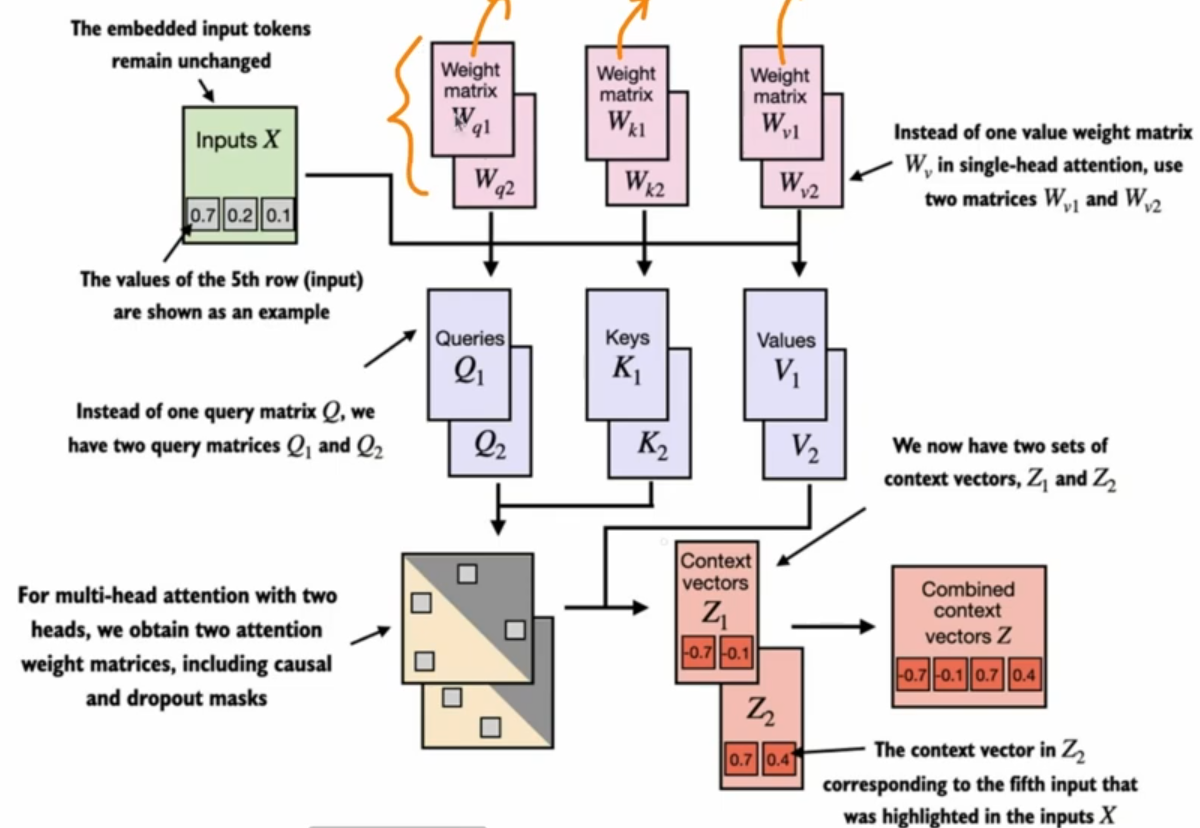

In [8]:
from IPython.display import Image
Image("images/stage1_9_multi_head_attn.png", width=800)


In [2]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [
            CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) for _ in range(num_heads)
            ]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [3]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # your     x^1
     [0.55, 0.87, 0.66], # journey  x^2
     [0.57, 0.85, 0.64], # starts   x^3
     [0.22, 0.58, 0.33], # with     x^4
     [0.77, 0.25, 0.10], # one      x^5
     [0.05, 0.80, 0.55]] # step     x^6
)

batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [4]:
torch.manual_seed(123)
context_length = batch.shape[1] # this is the context length of the input sequence, which is 6 in this case
d_in, d_out = 3, 2 # this is the dimensionality of the input token vectors

mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, dropout=0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs.shape)


torch.Size([2, 6, 4])


In [5]:
print(context_vecs)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)


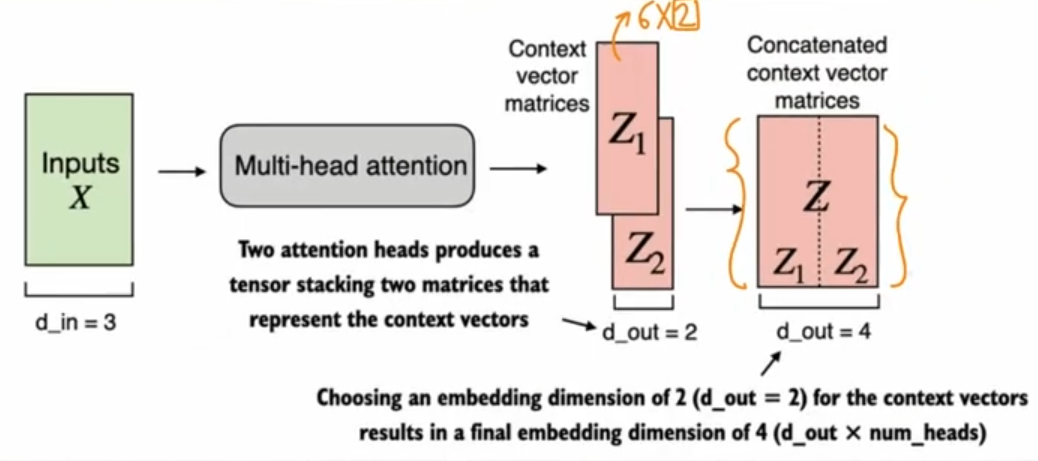

In [10]:

Image("images/staeg1_9_Conext_vector_stack.png", width=700)
